# Using Custom Datasets

In [65]:
import torch
from torch import nn

In [66]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists.


In [67]:
image_path

PosixPath('data/pizza_steak_sushi')

In [68]:
import os
def walk_through(dir_path) :
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [69]:
walk_through(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [70]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

data/pizza_steak_sushi/train/sushi/2873571.jpg
sushi
Random image path: data/pizza_steak_sushi/train/sushi/2873571.jpg
Image class: sushi
Image height: 287
Image width: 512


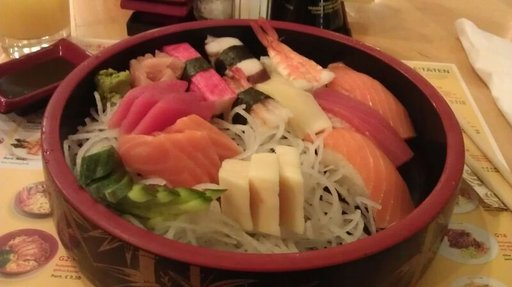

In [71]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.stem
print(image_class)

img = Image.open(random_image_path)
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

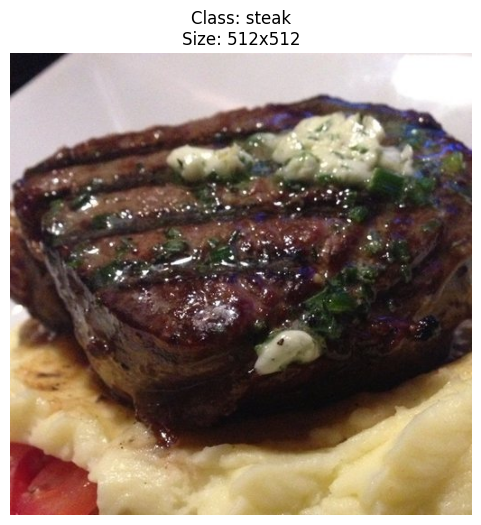

In [72]:
import matplotlib.pyplot as plt

random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Class: {image_class}\nSize: {img.width}x{img.height}")
plt.axis("off")
plt.show()

In [73]:
import numpy as np

img_array = np.array(img)
print(img_array.shape)

(512, 512, 3)


In [74]:
import torch

from torchvision import datasets, transforms

In [75]:
data_transform = transforms.Compose([
    transforms.Resize(size =(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [76]:
data_transform(img).shape

torch.Size([3, 64, 64])

Matplotlib accepts images in format (H,W,C) only so .permute(...) used

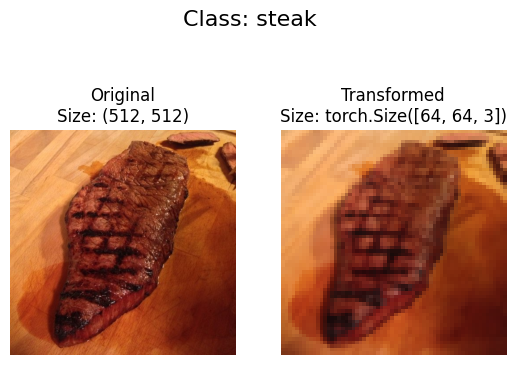

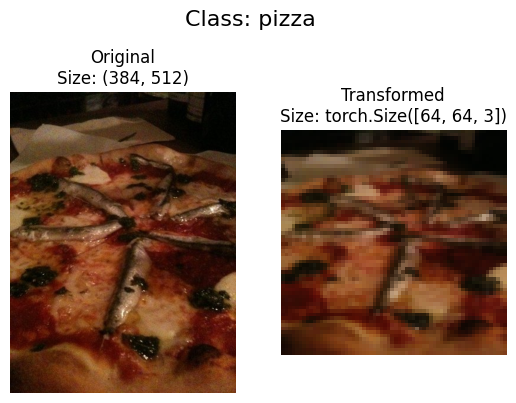

In [77]:
def plot_transformed_images(image_paths, transform, n=3, seed=None) :
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
      with Image.open(image_path) as f :
        fig,ax = plt.subplots(nrows=1, ncols=2)
        ax[0].imshow(f)
        ax[0].set_title(f"Original\nSize: {f.size}")
        ax[0].axis('off')

        transformed_image = transform(f).permute(1,2,0) #(C,H,W) -> (H,W,C)
        ax[1].imshow(transformed_image)
        ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
        ax[1].axis('off')

        fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
        plt.show()
plot_transformed_images(image_path_list, data_transform, n=2, seed=0)


In [78]:
from torchvision import datasets
train_data = datasets.ImageFolder(root= train_dir, transform= data_transform)
test_data = datasets.ImageFolder(root= test_dir, transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [79]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [80]:
len(train_data), len(test_data)

(225, 75)

In [81]:
import os
os.cpu_count()

2

In [82]:
# Dataset -> dataLoader
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset= train_data,
                              batch_size = BATCH_SIZE,
                              num_workers = 1,
                              shuffle=True)
test_dataloader = DataLoader(dataset= test_data,
                              batch_size = BATCH_SIZE,
                              num_workers = 1,
                              shuffle=False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7980eac5f9e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7980eac69fa0>)

In [83]:
len(train_dataloader), len(test_dataloader)

(8, 3)

## Data Augmentation

In [84]:
# https://docs.pytorch.org/vision/main/generated/torchvision.transforms.v2.TrivialAugmentWide.html

train_transforms = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transforms= transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [85]:
image_path

PosixPath('data/pizza_steak_sushi')

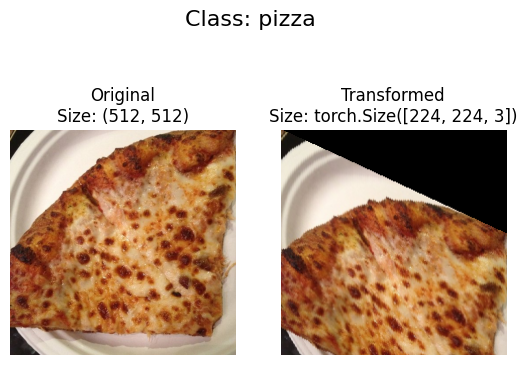

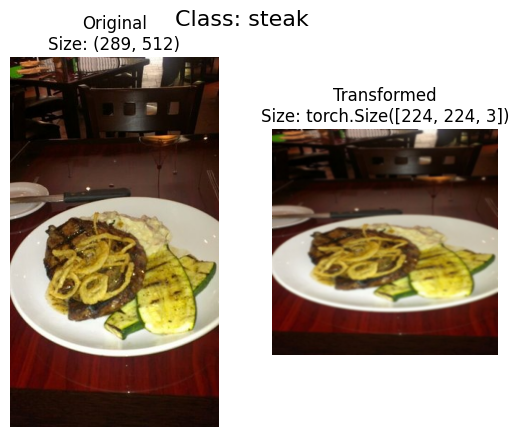

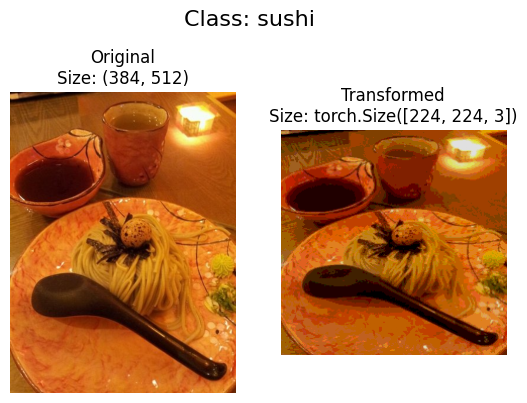

In [86]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Plot random images
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None
)

## Buidling Model

In [87]:
simple_tranform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [88]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_tranform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_tranform)

# Datasets -> DataLoader

import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                      batch_size=BATCH_SIZE,
                                      num_workers=os.cpu_count(),
                                      shuffle=True)
test_dataloader = DataLoader(dataset=test_data_simple,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

In [89]:
# TinyVGG architecture

class TinyVGG(nn.Module) :
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels= input_shape, out_channels= hidden_units, kernel_size=3,stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units, out_channels= hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units,
                  out_channels= hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.LazyLinear(output_shape)
    )
  def forward(self,x) :
    x = self.conv_block_1(x)

    x = self.conv_block_2(x)

    x = self.classifier(x)

    return x
    # return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [90]:
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data_simple.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): LazyLinear(in_features=0, out_features=3, bias=True)
  )
)

In [91]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader_simple))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
# model_0.eval()
# with torch.inference_mode():
#     pred = model_0(img_single.to(device))

# # 4. Print out what's happening and convert model logits -> pred probs -> pred label
# print(f"Output logits:\n{pred}\n")
# print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
# print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
# print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 224, 224])



In [92]:
# Install torchinfo if it's not available, import it if it is
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64]) # do a test pass through of an example input size

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [93]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [94]:
# Training
def train_step(model, dataloader, loss_fn, optimizer):
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X,y) in enumerate (dataloader) :
      X, y = X.to(device), y.to(device) # Move data to device
      y_pred = model(X)
      loss = loss_fn(y_pred,y)
      train_loss += loss.item()
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [95]:
def test_step(model, dataloader,loss_fn) :
  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode() :
    for batch, (X,y) in enumerate (dataloader) :
        X, y = X.to(device), y.to(device) # Move data to device
        test_pred_logits = model(X)
        loss = loss_fn(test_pred_logits, y)
        test_loss += loss.item()

        test_pred_labels = test_pred_logits.argmax(dim=1)
        test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [96]:
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn,epochs = 5):
  results = {'train_loss':[], 'test_loss':[], 'test_acc':[], 'train_acc':[]}

  for epoch in range(epochs) :
    train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer)
    test_loss, test_acc = test_step(model, test_dataloader, loss_fn)
    if epoch % 10 == 0 :
      print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)

  return results

In [100]:
NUM_EPOCHS = 30

model_0 = TinyVGG(input_shape=3, hidden_units = 10, output_shape=len(train_data.classes))

model_0 = model_0.to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)


Epoch: 1 | Train Loss: 1.1157 | Train Acc: 0.2734 | Test Loss: 1.0996 | Test Acc: 0.2083
Epoch: 11 | Train Loss: 0.8093 | Train Acc: 0.5820 | Test Loss: 0.9175 | Test Acc: 0.4735
Epoch: 21 | Train Loss: 0.1448 | Train Acc: 0.9453 | Test Loss: 1.4233 | Test Acc: 0.5028


In [101]:
# Check the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'test_loss', 'test_acc', 'train_acc'])

In [102]:
def plot_loss_curves(results) :
  loss = results['train_loss']
  accuracy = results['train_acc']

  test_loss = results['test_loss']
  test_accuracy = results['test_acc']

  epochs = range(len(results['train_loss']))

  plt.figure(figsize=(10,7))
  plt.subplot(1,2,1)
  plt.plot(epochs, loss, label='train_loss')
  plt.plot(epochs, test_loss, label='test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy, label='train_accuracy')
  plt.plot(epochs, test_accuracy, label='test_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')

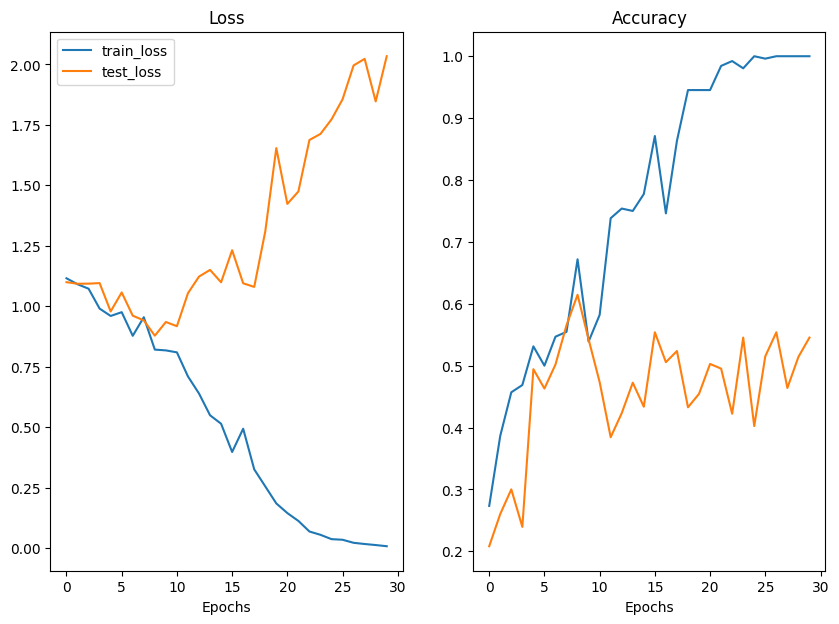

In [103]:
plot_loss_curves(results= model_0_results)

In [104]:
train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])


In [105]:
train_data_aug = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transform)

In [106]:
BATCH_SIZE =32

train_dataloader_aug = DataLoader(dataset=train_data_aug,
                                 batch_size=BATCH_SIZE,
                                 num_workers=os.cpu_count(),
                                 shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

In [107]:
model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data_aug.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): LazyLinear(in_features=0, out_features=3, bias=True)
  )
)

In [110]:
NUM_EPOCHS= 30

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)


In [111]:
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_aug,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)


Epoch: 1 | Train Loss: 0.8620 | Train Acc: 0.6172 | Test Loss: 0.9449 | Test Acc: 0.5237
Epoch: 11 | Train Loss: 0.8924 | Train Acc: 0.4922 | Test Loss: 0.9635 | Test Acc: 0.4347
Epoch: 21 | Train Loss: 0.8094 | Train Acc: 0.6055 | Test Loss: 0.9487 | Test Acc: 0.5057


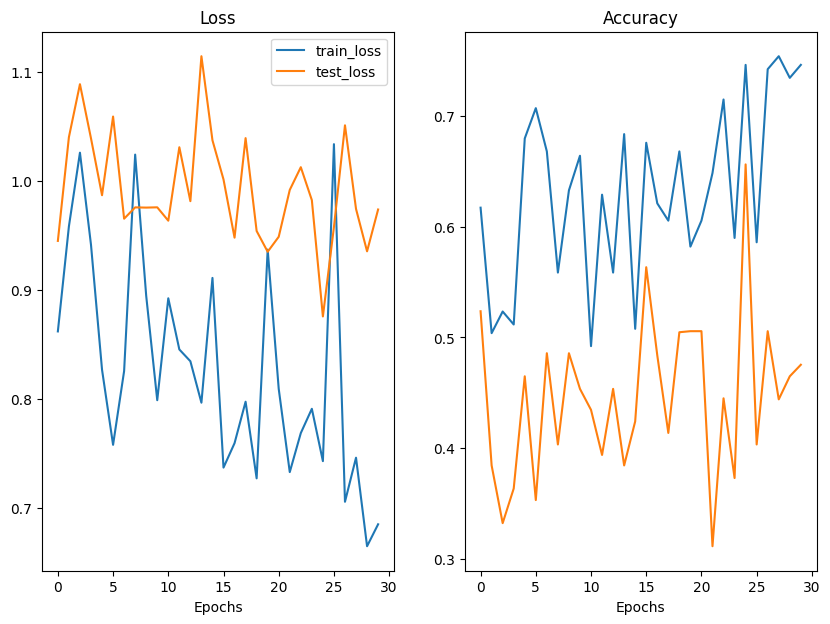

In [112]:
plot_loss_curves(model_1_results)

In [113]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,test_loss,test_acc,train_acc
0,1.115680,1.099628,0.208333,0.273438
1,1.091119,1.093074,0.260417,0.386719
2,1.072603,1.093499,0.300189,0.457031
3,0.990291,1.095782,0.239583,0.468750
4,0.959844,0.978557,0.494318,0.531250
5,0.975518,1.057102,0.463068,0.500000
6,0.877829,0.961026,0.501894,0.546875
7,0.954692,0.941655,0.565341,0.554688
8,0.820755,0.878261,0.614583,0.671875
9,0.817490,0.934926,0.542614,0.539062


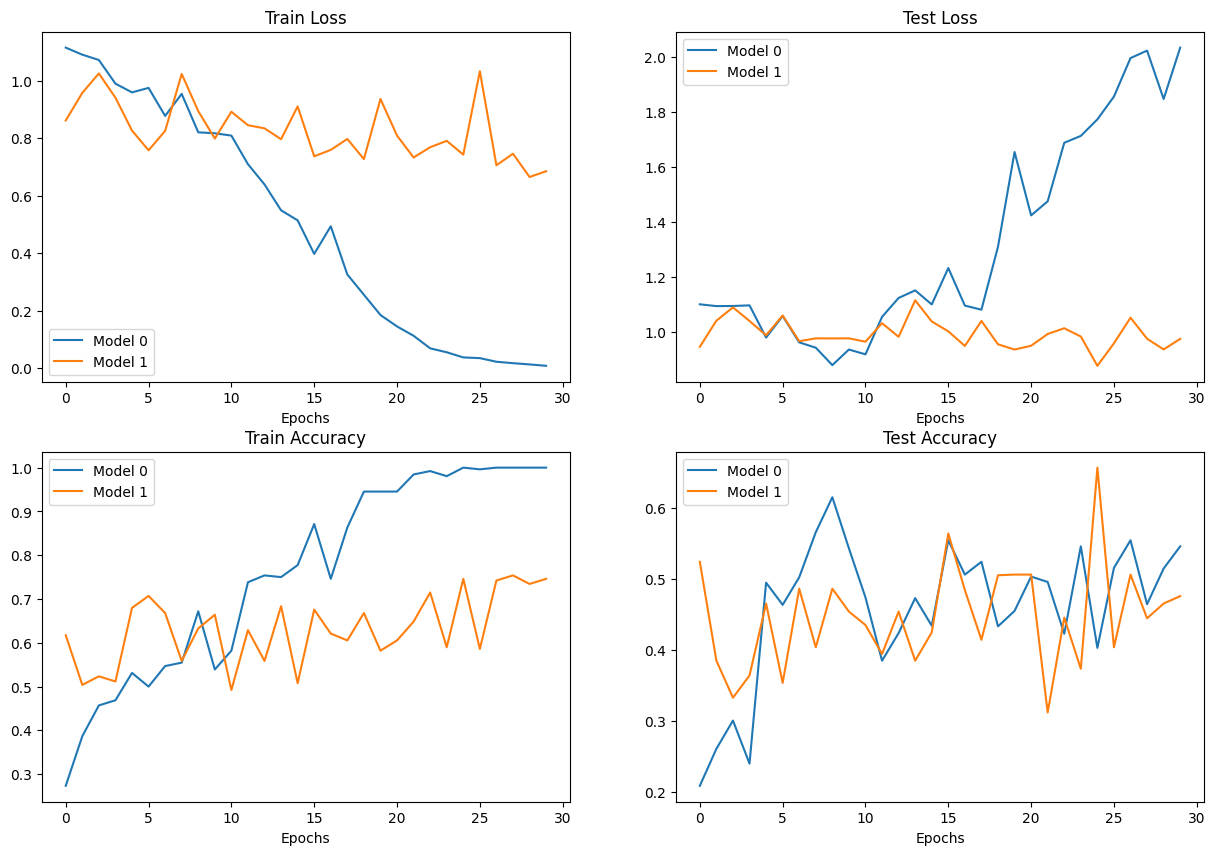

In [114]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

In [115]:
## Next step -> Predict eval on custom image o your own